In [ ]:
# Should be exec first in a fresh venv
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
import scanpy as sc
import numpy as np
from tqdm import tqdm
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../../')
import GM

# Read adata containing structured latent

In [2]:
adata_structured = sc.read_h5ad(
    'adata_structured_balanced.h5ad'
)

adata = sc.AnnData(
    adata_structured.obsm['mapped_latent'].copy(),
    obs=adata_structured.obs.copy(),
    obsm=adata_structured.obsm.copy()
)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata.obs['level'].min(), adata.obs['level'].max()

(1, 16)

# Get tree

In [4]:
tree_results = GM.get_tree(
    adata, 
    cell_type_key='cell_type',
    )

using step=1
n_comps: 30


In [5]:
assert tree_results['linkage_mtx'].shape[0] == len(tree_results['clusters']) - 1
assert tree_results['linkage_mtx'].shape[1] == 4

# Plot Tree

In [6]:
save_path =f'{FIG_ROOT}/Leukemia/dendro'
os.makedirs(save_path, exist_ok=True)

In [7]:
desired_order=[
    'CD4+ Naive T cells', 'CD4+ Central/Effector memory T cells (CM/EM)',  
    'CD8+ Eff/Mem T cells (EM)', 'CD8+ Effector T cells (E)', 'CD8+ Cytotoxic T cells', 'gamma-delta T cells', 
    'Early prolif: MCM3/5/7+ PCNA+ T cells', 'Late prolif: STMN1+ BIRC5+', 'Late prolif: CCNB1/2+ CDK1+ T cells',
    'Late prolif: histones enriched MKI67+ T cells'
]

saving to /data/scDisentangle_paper_figures/Leukemia/dendro/dendro


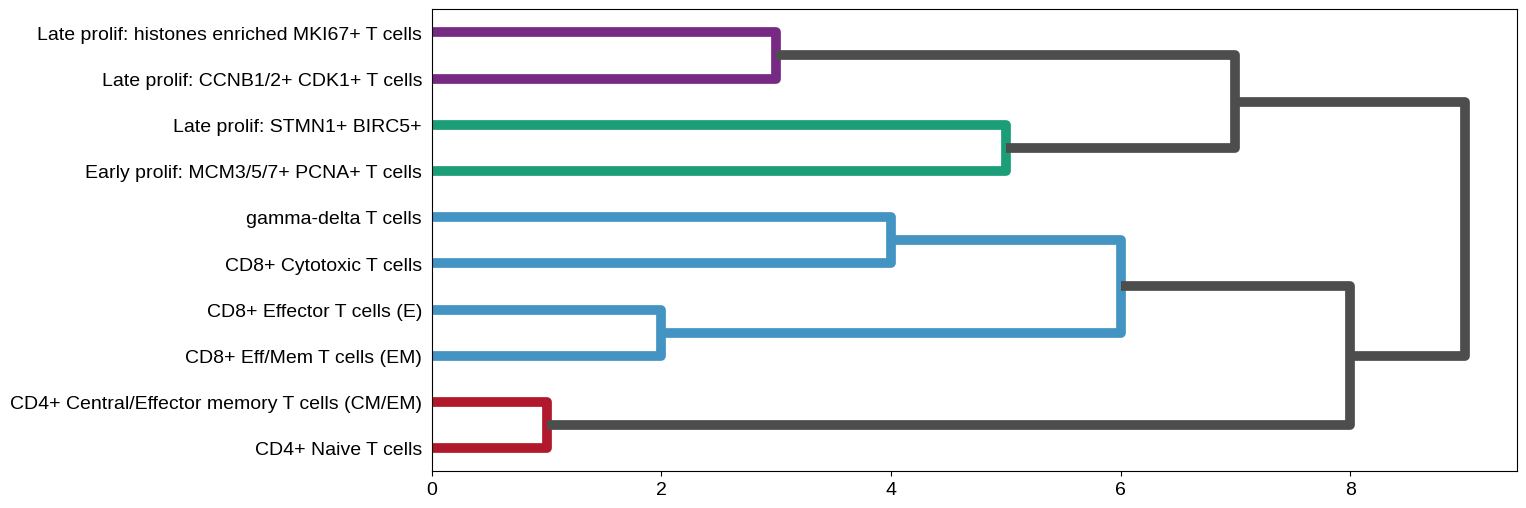

In [8]:
leaf_order = GM.plot_dendro(
    linkage_mtx=tree_results['linkage_mtx'], 
    clusters=tree_results['clusters'], 
    figsize=(14, 6),
    linewidth=7,
    orientation='right',
    save_path=f'{save_path}/dendro',
    desired_order=desired_order
    )

# Stability across seeds

In [9]:
Z_list = []
clusters = []
for seed_nb in tqdm(range(30)):
    tree_results = GM.get_tree(
        adata, 
        cell_type_key='cell_type',
        random_state=seed_nb,
        )
    
    Z_list.append(tree_results['linkage_mtx'])
    clusters.append(tree_results['clusters'])


cluster_0 = clusters[0]
for _c in clusters:
    assert _c == cluster_0

k = 3

support = None
for Z in Z_list:
    labels = fcluster(Z, t=k, criterion="maxclust")          # (n_leaves,)
    same = (labels[:, None] == labels[None, :]).astype(float) # (n_leaves, n_leaves)
    support = same if support is None else (support + same)

support /= len(Z_list)  # (n_leaves, n_leaves) in [0,1]

  0%|                                                                                                                                                                                       | 0/30 [00:00<?, ?it/s]

using step=1
n_comps: 30


  3%|█████▊                                                                                                                                                                         | 1/30 [01:37<47:19, 97.92s/it]

using step=1
n_comps: 30


  7%|███████████▌                                                                                                                                                                  | 2/30 [03:22<47:28, 101.74s/it]

...

 93%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍           | 28/30 [45:15<03:07, 93.85s/it]

using step=1
n_comps: 30


 97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏     | 29/30 [46:49<01:33, 93.82s/it]

using step=1
n_comps: 30


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [48:26<00:00, 96.88s/it]


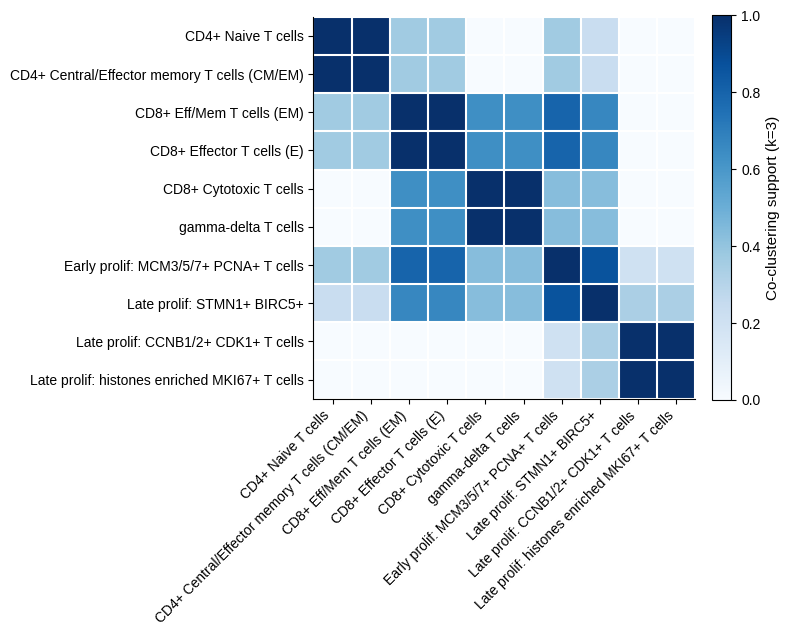

In [10]:
leaf_names = cluster_0
n = len(leaf_names)
fig, ax = plt.subplots(figsize=(0.55*n + 2.5, 0.55*n + 2.0))

if leaf_order is not None:
    # Reorder rows & columns
    leaf_names = [leaf_names[i] for i in leaf_order]
    support = support[np.ix_(leaf_order, leaf_order)]
    
im = ax.imshow(
    support,
    vmin=0, vmax=1,
    cmap="Blues",
    interpolation="nearest",
    aspect="equal",
)

# ticks/ labels
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(leaf_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(leaf_names, fontsize=10)

# gridlines
ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(f"Co-clustering support (k={k})", fontsize=11)

fig.tight_layout()
plt.savefig(f'{save_path}/support_seed.png', dpi=500)
plt.savefig(f'{save_path}/support_seed.pdf', dpi=500)